In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
# from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

estimating categorical probs
estimating approx kdes(histogram)
[0.6827952233524989]
Attacking : Raw
Generated datasest of Raw stored at :data/generated_datasets/Raw.pkl
COMPLEXITY:  2
COMPLEXITY:  20


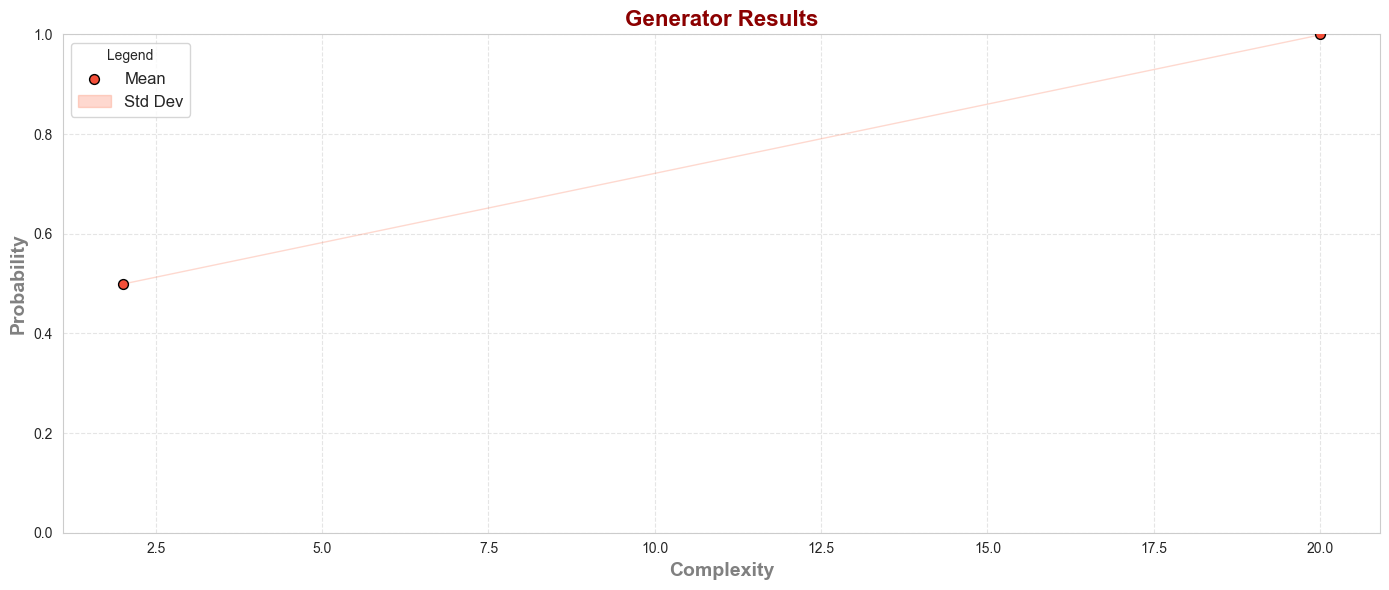

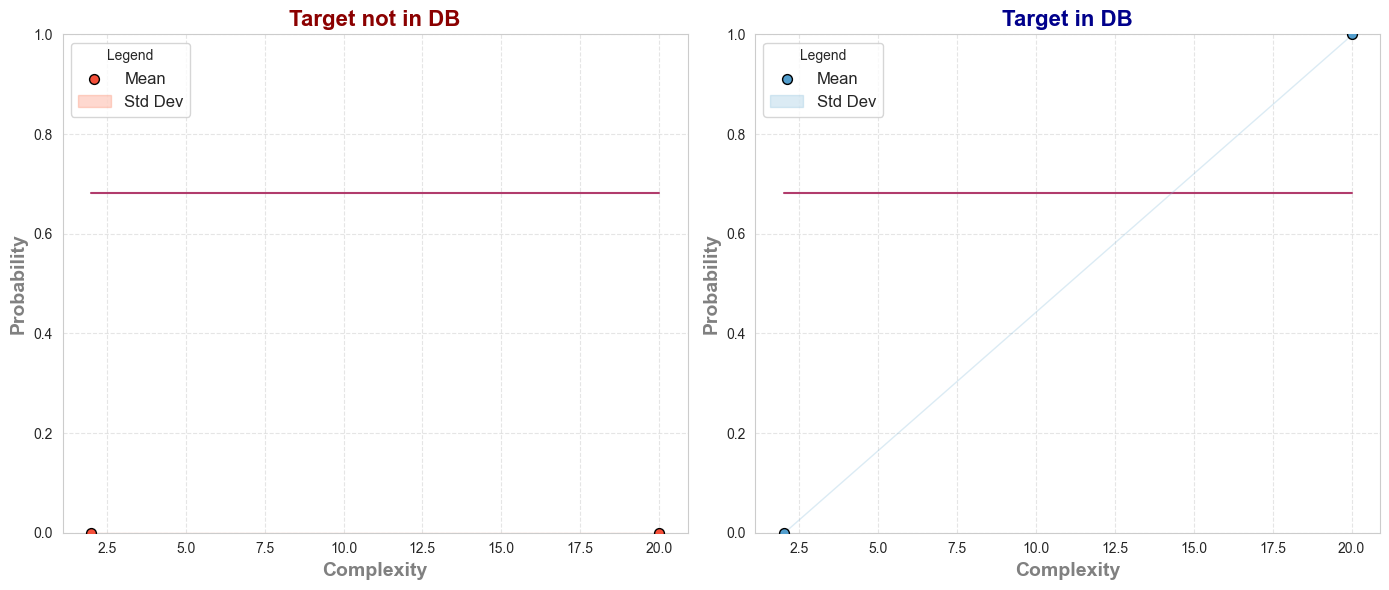

Attacking : Raw
Generated datasest of Raw stored at :data/generated_datasets/Raw.pkl
COMPLEXITY:  2
COMPLEXITY:  20


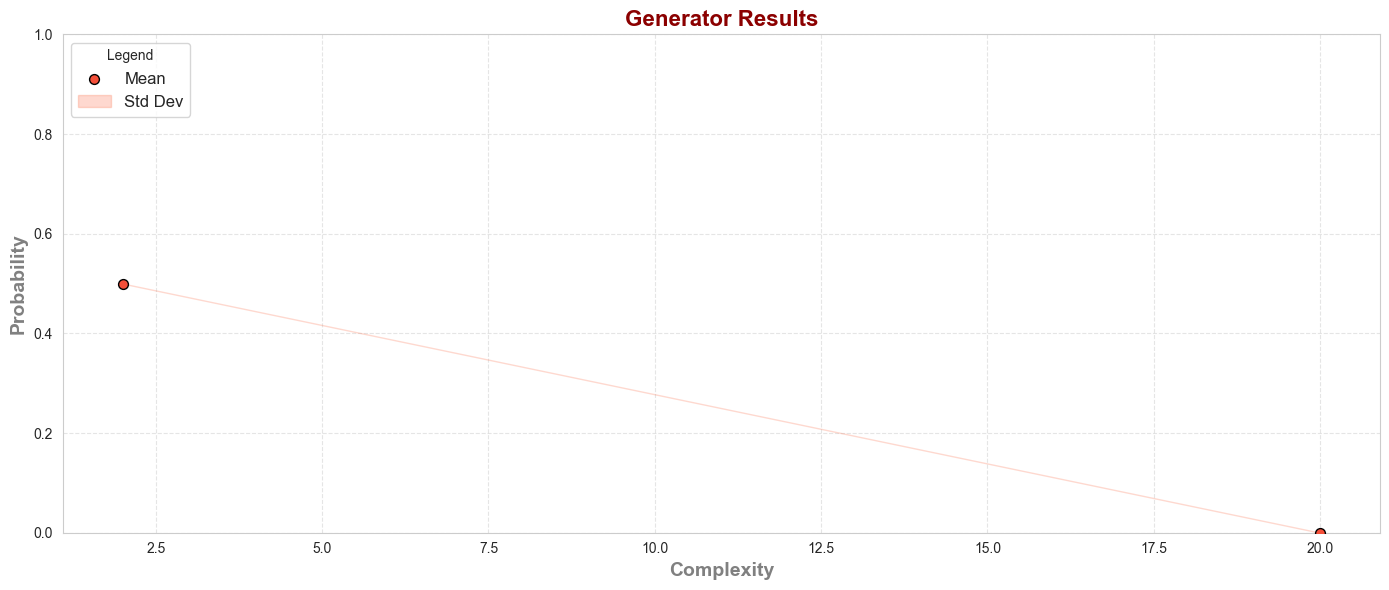

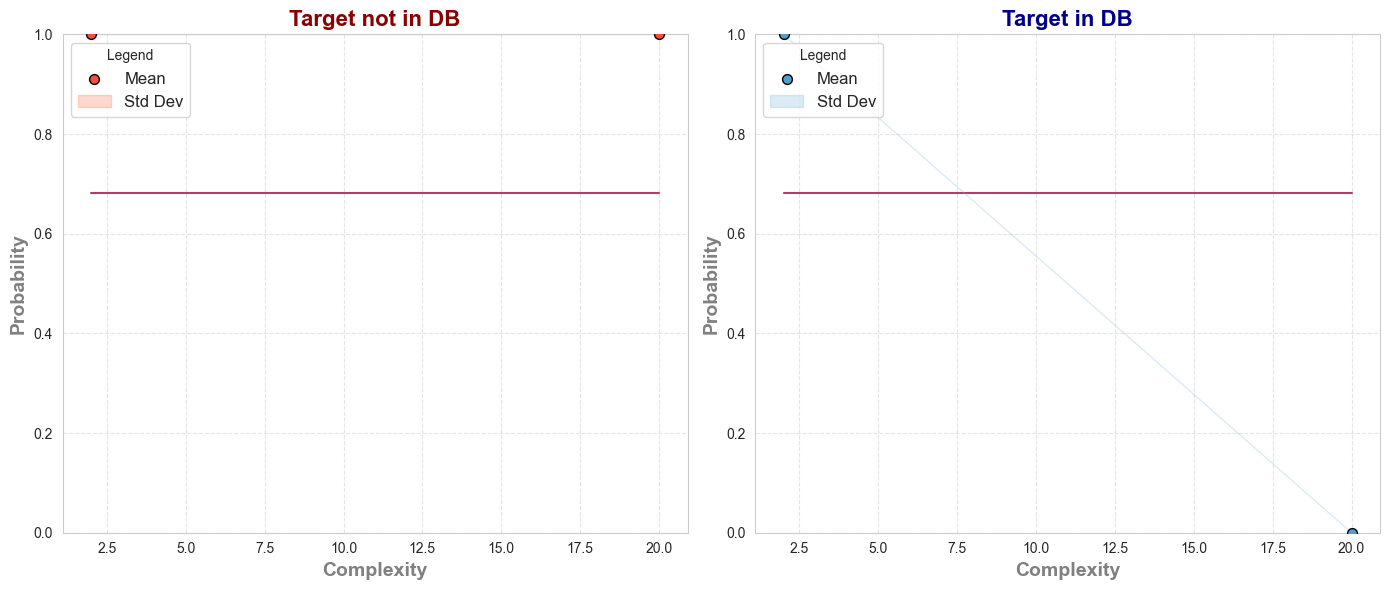

----[Benchmark ranks]----
Raw : E, 0.75
Raw : B, 0.25
Raw was not broken by the attack
Generators Metrics saved to results/2025_05_20_20_38/generators_metrics.csv
Attack results saved to results/2025_05_20_20_38/attack_results.yaml


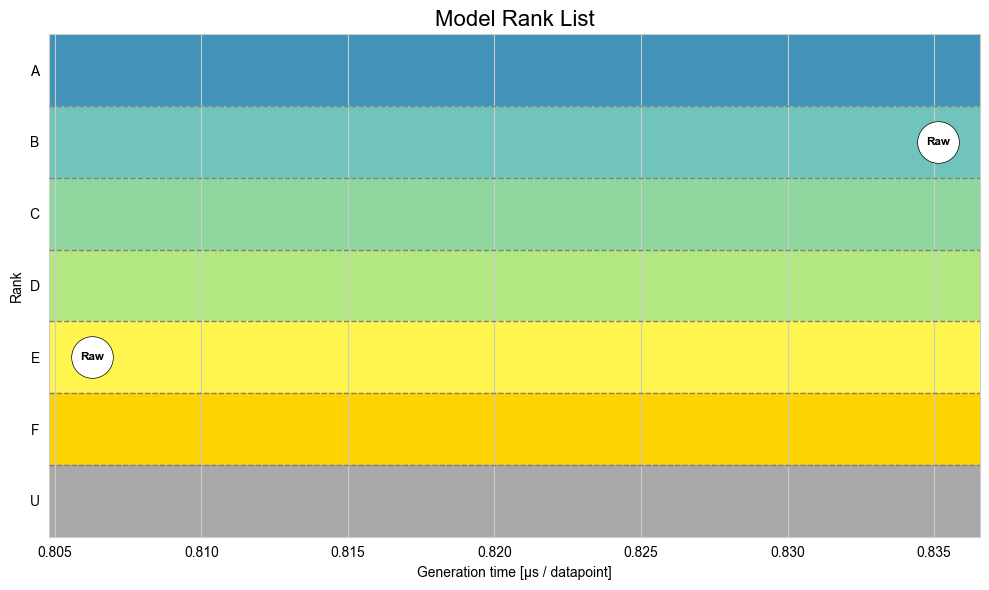

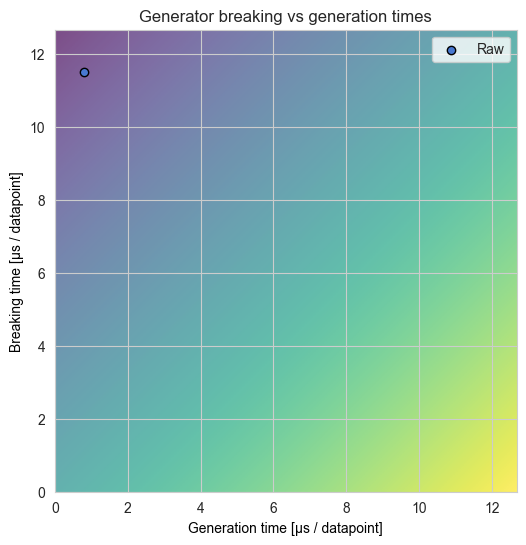

Evaluating original data
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:25] WARN

Evaluating : Raw
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:38:55] WARN

Evaluating : Raw
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:39:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:39:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:39:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/Cellar/micromamba/2.1.1/envs/lab_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:39:24] WARN

Results saved to results/2025_05_20_20_38/results_ml_utility.csv
Evaluating : Raw
Evaluating : Raw


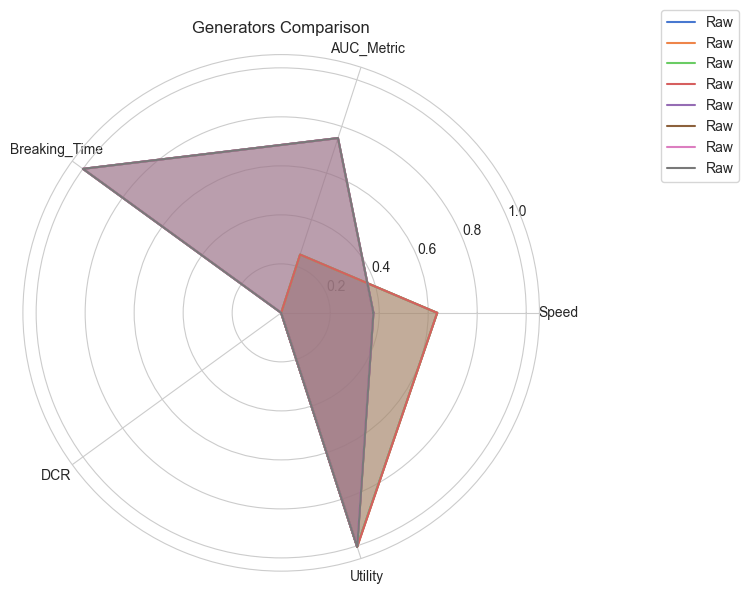

In [2]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,3,2))

# gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(), Raw()], target_record=target_record)
benchmarking_metric = AUCMetric()


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='all', benchmarking_metric=benchmarking_metric, 
classification_target_col="income", dcr_metric="gower", generate_data=True)